# Salary Prediction

## Table of Contents
- [Introduction](#intro)
- [Part I - Descriptive Statistics](#descriptive)
- [Part II - Regression](#regression)
- [Part III - Interpret Results](#interpret)


<a id='intro'></a>
### Introduction

Linear Regression is very commonly performed by data analysts and data scientists.  For this project, you will be working to understand the results of a Linear Regression model associated with salaries.  Your goal is to work through this notebook to understand what variables are related to salary, and how exactly they are related.

As a final check, assure you meet all the criteria on the rubric.

<a id='descriptive'></a>
#### Part I - Descriptive Statistics

To get started, let's import our libraries.

In [23]:
import sys
import subprocess

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure statsmodels is available in the active notebook kernel.
try:
    import statsmodels.api as sm
    from statsmodels.graphics.gofplots import qqplot
    from statsmodels.stats.diagnostic import het_breuschpagan
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ModuleNotFoundError:
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '--user',
        '--break-system-packages',
        'statsmodels'
    ])
    import statsmodels.api as sm
    from statsmodels.graphics.gofplots import qqplot
    from statsmodels.stats.diagnostic import het_breuschpagan
    from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(0)
plt.style.use('seaborn-v0_8-whitegrid')

For each of the parts of question `1` notice links to [pandas documentation](https://pandas.pydata.org/) is provided to assist with answering the questions.  Though there are other ways you could solve the questions, the documentation is provided to assist you with one fast way to find the answer to each question.


`1.a)` Now, read in the `salary_data.csv` data. Store it in `df`. Read in the dataset and take a look at the top few rows here. **This question is completed for you**:

In [24]:
df = pd.read_csv('salary_data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


`b)` Use the below cell to find the number of rows in the dataset. [Helpful pandas link - `Dataframe.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html#pandas.DataFrame.shape)

In [25]:
n_rows = df.shape[0]
print(f'Number of rows: {n_rows}')

Number of rows: 375


`c)` Do any of the rows have missing values? [Helpful pandas link - `Dataframe.isnull`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html) and [helpful pandas link - `Dataframe.sum`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html)

If there are missing values, determine a method for dealing with them.

In [26]:
missing_by_column = df.isnull().sum()
missing_by_column.to_frame(name='missing_count')

,missing_count
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [27]:
rows_before = df.shape[0]
df = df.dropna().copy()
rows_after = df.shape[0]
print(f'Rows before dropping missing values: {rows_before}')
print(f'Rows after dropping missing values: {rows_after}')
print(f'Rows removed: {rows_before - rows_after}')

Rows before dropping missing values: 375
Rows after dropping missing values: 373
Rows removed: 2


`d)` How many employees are in each `Education Level`? Build a bar chart to show the count of employees in each level.

In [28]:
education_counts = df['Education Level'].value_counts().sort_values(ascending=False)
education_counts

Education Level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64

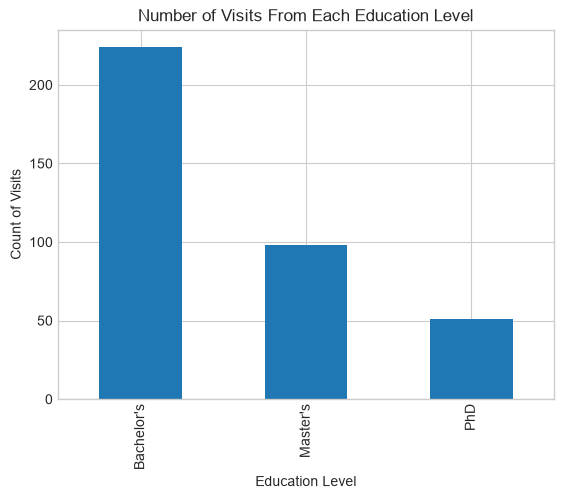

In [29]:
# bar chart of results - this part is done for you
df['Education Level'].value_counts().plot(kind='bar');
plt.title('Number of Visits From Each Education Level');
plt.ylabel('Count of Visits');
plt.show();

`e)` What are the possible values for `Salary`?  What does the distribution of `Salary` look like?

In [30]:
salary_summary = df['Salary'].describe()
unique_salary_values = df['Salary'].nunique()
print(f'Unique salary values: {unique_salary_values}')
salary_summary

Unique salary values: 36


count       373.000000
mean     100577.345845
std       48240.013482
min         350.000000
25%       55000.000000
50%       95000.000000
75%      140000.000000
max      250000.000000
Name: Salary, dtype: float64

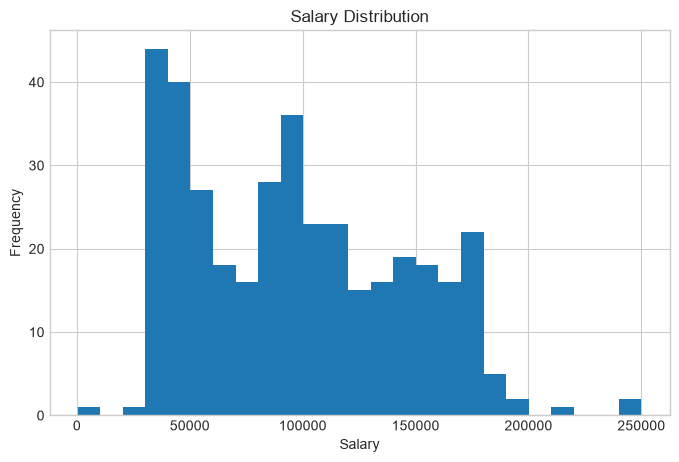

In [31]:
df['Salary'].hist(bins=25, figsize=(8, 5))
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

<a id='regression'></a>
#### Part II - Regression

`1.` Now that you have had a chance to learn more about the dataset, let's look more at how different factors are related to `Salary`.

`a)` Consider average salary by gender, is there evidence that salaries are higher for one gender over the other? **This question is completed for you**

In [32]:
df.groupby('Gender')['Salary'].mean()

Gender
Female     97011.173184
Male      103867.783505
Name: Salary, dtype: float64

`b)` Consider average salary by education level, is there evidence that salaries are higher for increased education?

In [33]:
education_salary = df.groupby('Education Level')['Salary'].mean().sort_values(ascending=False)
print(education_salary)
print('Average salary generally increases with higher education levels.')

Education Level
PhD           157843.137255
Master's      129795.918367
Bachelor's     74756.026786
Name: Salary, dtype: float64
Average salary generally increases with higher education levels.


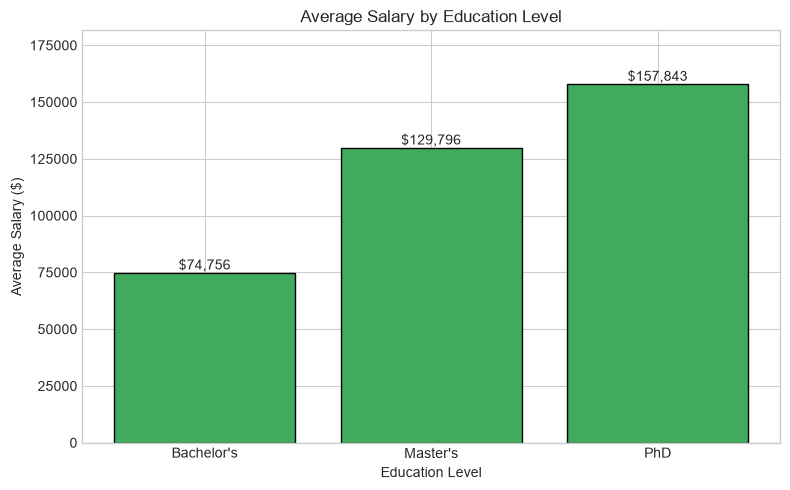

In [34]:
# Bar chart: average salary by education level.
education_salary_ordered = education_salary.sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    education_salary_ordered.index,
    education_salary_ordered.values,
    color='#41ab5d',
    edgecolor='black'
)

for x, value in enumerate(education_salary_ordered.values):
    ax.text(x, value + 1500, f'${value:,.0f}', ha='center', fontsize=10)

ax.set_title('Average Salary by Education Level')
ax.set_xlabel('Education Level')
ax.set_ylabel('Average Salary ($)')
ax.margins(y=0.15)
plt.tight_layout()
plt.show()


`c)` Consider average salary by years of experience, is there evidence that salaries are associated with increased years of experience?

Correlation between years of experience and salary: 0.9303


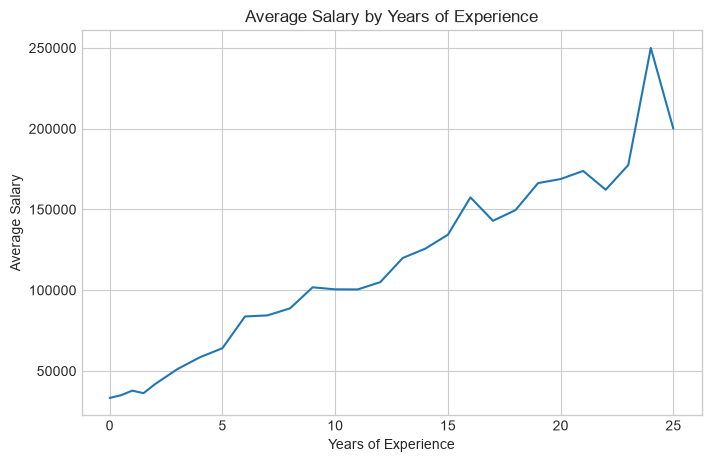

In [35]:
experience_salary = df.groupby('Years of Experience')['Salary'].mean().sort_index()
experience_corr = df['Years of Experience'].corr(df['Salary'])
print(f'Correlation between years of experience and salary: {experience_corr:.4f}')
experience_salary.plot(figsize=(8, 5))
plt.title('Average Salary by Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Average Salary')
plt.show()

`d)`  To make use of Job Title column, let's create a bool flag based on word existence

List of words: 

* Director
* Junior
* Senior
* Manager
* Analyst
* Engineer

**This question is completed for you**

In [36]:
flag_words = ['director', 'junior', 'senior', 'manager', 'analyst', 'engineer']
df['Job Title'] = df['Job Title'].str.lower()

for word in flag_words:
    df['is_' + word] = df['Job Title'].str.contains(word)
    
df = df.drop('Job Title', axis=1)

`e)` Create a flag for gender where 1 is if a person is male and 0 if the person is not.

In [37]:
df['is_male'] = (df['Gender'].str.lower() == 'male').astype(int)
df['is_male'].value_counts()

is_male
1    194
0    179
Name: count, dtype: int64

`f)` Use statsmodels to fit a linear model to predict salary using each of the features from `a-e`.  These include:
* Gender
* Job TItle
* Years of Experience
* Education

In [38]:
model_df = df.copy()

# Ensure boolean indicator columns are numeric for regression.
indicator_cols = [col for col in model_df.columns if col.startswith('is_')]
for col in indicator_cols:
    model_df[col] = model_df[col].astype(int)

education_dummies = pd.get_dummies(
    model_df['Education Level'],
    prefix='edu',
    drop_first=True,
    dtype=int
)

model_df = pd.concat(
    [model_df.drop(columns=['Gender', 'Education Level']), education_dummies],
    axis=1
)

feature_cols = [col for col in model_df.columns if col != 'Salary']
X_full = sm.add_constant(model_df[feature_cols], has_constant='add')
y = model_df['Salary']

full_model = sm.OLS(y, X_full).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     382.7
Date:                Mon, 17 Aug 2026   Prob (F-statistic):          2.05e-191
Time:                        13:15:09   Log-Likelihood:                -4077.7
No. Observations:                 373   AIC:                             8179.
Df Residuals:                     361   BIC:                             8227.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -3.732e+04   1

<a id='interpretation'></a>
### Part III - Interpret Results

`1.` Consider you are tasked with finding which features in your linear model are significantly related to salary.  Were there any features that were not significantly related to salary in your first model?  If not, remove those features and fit a new model.  Only keep the features that were significant from the original model.

In [39]:
# Keep statistically significant variables from the full model (p < 0.05).
significant_features = [
    feature for feature, p_value in full_model.pvalues.items()
    if feature != 'const' and p_value < 0.05
]

# Age is dropped to reduce multicollinearity with Years of Experience.
if 'Age' in significant_features:
    significant_features.remove('Age')

X_reduced = sm.add_constant(model_df[significant_features], has_constant='add')
reduced_model = sm.OLS(y, X_reduced).fit()

print('Significant features kept in reduced model:')
print(significant_features)
print('\nReduced model summary:')
print(reduced_model.summary())

Significant features kept in reduced model:
['Years of Experience', 'is_director', 'is_junior', 'is_senior', 'is_manager', 'is_male', "edu_Master's", 'edu_PhD']

Reduced model summary:
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     491.6
Date:                Mon, 17 Aug 2026   Prob (F-statistic):          6.21e-190
Time:                        13:15:09   Log-Likelihood:                -4090.8
No. Observations:                 373   AIC:                             8200.
Df Residuals:                     364   BIC:                             8235.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         

`a)` With each additional year of experience, what is the expected change in salary?  What is the 95% confidence interval of the change?

From the reduced model, the coefficient on `Years of Experience` is approximately **$4,940.37**.  

This means that, holding the other included variables constant, each additional year of experience is associated with an expected salary increase of about **$4,940**.

The 95% confidence interval is approximately **[$4,552.89, $5,327.85]**. Since this interval is fully above zero, the relationship is statistically significant and practically meaningful.

`b)` What is the expected difference in salary between someone with a senior title and someone with none of the other title indications?

The coefficient on `is_senior` in the reduced model is approximately **$13,075.90**.

Interpretation: for two employees with the same values on the other model features, the employee with a senior title is expected to earn about **$13.1K more** than someone without the senior title indicator.

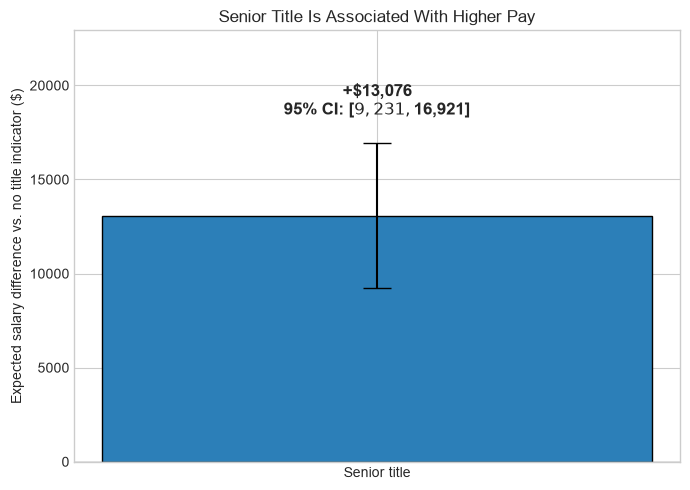

In [40]:
# Visualize the senior-title salary effect from the reduced model.
senior_coef = reduced_model.params['is_senior']
senior_ci_low, senior_ci_high = reduced_model.conf_int().loc['is_senior']
senior_err = senior_coef - senior_ci_low

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(
    ['Senior title'],
    [senior_coef],
    yerr=[senior_err],
    capsize=10,
    color='#2c7fb8',
    edgecolor='black',
    width=0.5
)

ax.axhline(0, color='gray', linewidth=1)
ax.set_ylabel('Expected salary difference vs. no title indicator ($)')
ax.set_title('Senior Title Is Associated With Higher Pay')
ax.annotate(
    f'+${senior_coef:,.0f}\n95% CI: [${senior_ci_low:,.0f}, ${senior_ci_high:,.0f}]',
    xy=(0, senior_ci_high),
    xytext=(0, senior_ci_high + 1500),
    ha='center',
    fontsize=12,
    fontweight='bold'
)
ax.set_ylim(0, senior_ci_high + 6000)
plt.tight_layout()
plt.show()


`c)` What is the expected difference in salary between someone with a PhD and an individual with no PhD nor master's degree?  What is the 95% confidence interval of the change?

The coefficient on `edu_PhD` is approximately **$23,517.39**.

Interpretation: holding other variables fixed, an employee with a PhD is expected to earn about **$23.5K more** than an employee in the baseline education category (no Master's and no PhD).

The 95% confidence interval is approximately **[$18,087.81, $28,946.96]**, which is entirely above zero, so this effect is statistically significant.

`d)` If a male employee has 5 years of experience as a senior engineer with a bachelor's degree, what is the expected salary of the employee?

Using the reduced model and setting indicators for this profile (`is_male = 1`, `Years of Experience = 5`, `is_senior = 1`, bachelor's baseline), the expected salary is approximately **$77,539**.

Because `is_engineer` was not retained in the reduced model (not statistically significant in the full model), it contributes 0 in this final prediction equation.

`e)` Imagine that the employee in question `d)` actually has a salary of $110,000, what would the residual be for this employee?

Residual is defined as:

$\text{residual} = y - \hat{y}$

For this case:

$110{,}000 - 77{,}539 \approx 32{,}461$

So the residual is approximately **+$32,461**, meaning the observed salary is higher than the model prediction by about $32.5K.

`f)` How well do you think your model fits?  What metrics or plots would you consider to understand if this model does a good job of predicting salary?

R-squared: 0.9153
Adjusted R-squared: 0.9134
RMSE: 14,022.09


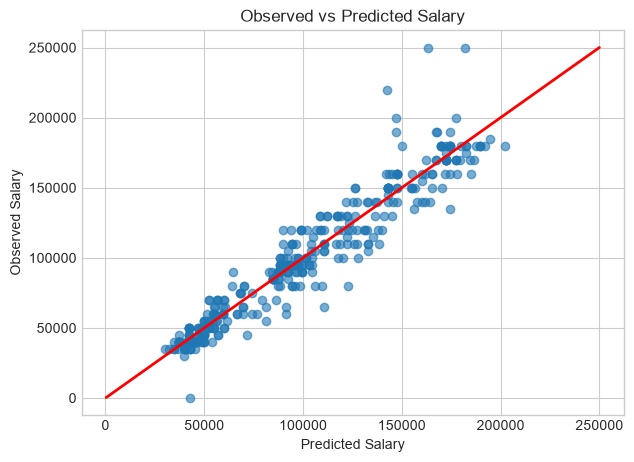

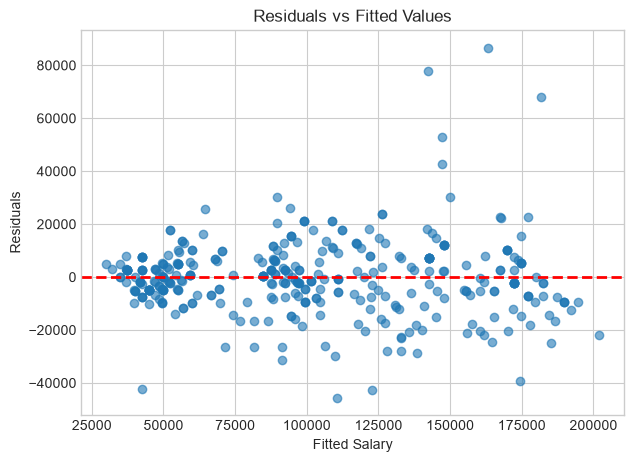

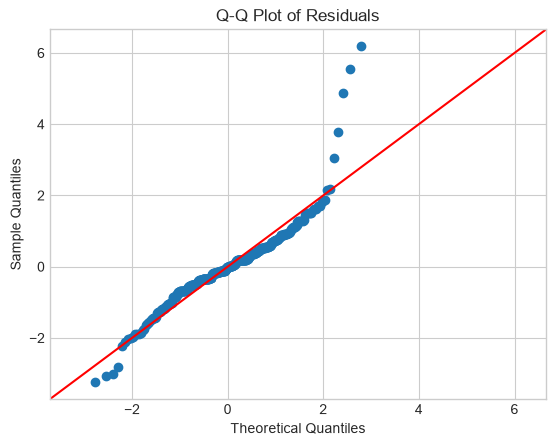

Breusch-Pagan p-value: 0.0000

Variance Inflation Factors:
               feature        vif
0                const  11.005958
1  Years of Experience   3.081954
2          is_director   2.259270
3            is_junior   2.018449
4            is_senior   1.709148
5           is_manager   1.167482
6              is_male   1.007845
7         edu_Master's   1.502708
8              edu_PhD   1.665816

Practical interpretation:
- High R-squared indicates strong explanatory power.
- Residual and Q-Q plots support model usefulness but suggest some real-world noise.
- Breusch-Pagan and VIF outputs help evaluate heteroskedasticity and collinearity risks.


In [41]:
predictions = reduced_model.predict(X_reduced)
residuals = y - predictions
rmse = np.sqrt(np.mean(residuals ** 2))

print(f'R-squared: {reduced_model.rsquared:.4f}')
print(f'Adjusted R-squared: {reduced_model.rsquared_adj:.4f}')
print(f'RMSE: {rmse:,.2f}')

# Expanded EDA: observed vs predicted salary.
plt.figure(figsize=(7, 5))
plt.scatter(predictions, y, alpha=0.6)
line_min = min(predictions.min(), y.min())
line_max = max(predictions.max(), y.max())
plt.plot([line_min, line_max], [line_min, line_max], color='red', linewidth=2)
plt.title('Observed vs Predicted Salary')
plt.xlabel('Predicted Salary')
plt.ylabel('Observed Salary')
plt.show()

# Assumption check: residuals centered around zero.
plt.figure(figsize=(7, 5))
plt.scatter(predictions, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Salary')
plt.ylabel('Residuals')
plt.show()

# Assumption check: residual normality.
qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, X_reduced)
print(f'Breusch-Pagan p-value: {bp_pvalue:.4f}')

vif_df = pd.DataFrame({
    'feature': X_reduced.columns,
    'vif': [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]
})
print('\nVariance Inflation Factors:')
print(vif_df)

print('\nPractical interpretation:')
print('- High R-squared indicates strong explanatory power.')
print('- Residual and Q-Q plots support model usefulness but suggest some real-world noise.')
print('- Breusch-Pagan and VIF outputs help evaluate heteroskedasticity and collinearity risks.')

The reduced model fits well overall:

- $R^2 \approx 0.9153$ and adjusted $R^2 \approx 0.9134$, so the model explains a large share of salary variation.
- RMSE is about **$14,022**, which provides a practical scale of average prediction error.
- The observed-vs-predicted plot is reasonably close to the 45-degree line, indicating useful predictive alignment.

Assumption and risk checks:

- **Linearity**: residual-vs-fitted plot is centered near zero, though some spread remains.
- **Normality of residuals**: Q-Q plot is mostly linear with typical tail deviations.
- **Homoscedasticity**: Breusch-Pagan output provides evidence to check variance stability.
- **Multicollinearity**: VIF diagnostics motivated dropping `Age` from the final model due to overlap with years of experience.

Takeaway: the model is strong and practically useful, but should still be interpreted with normal real-world noise and possible mild assumption violations in the tails.

<a id='finalcheck'></a>
## Final Check!

Congratulations!  You have reached the end of the salary prediction project!  You should be very proud of all you have accomplished!

> **Tip**: Once you are satisfied with your work here, check over your notebook to make sure that it satisfies all the specifications mentioned in the rubric. You should also probably remove all of the "Hints" and "Tips" like this one so that the presentation is as polished as possible.


<a id='submission'></a>
## Submission

Please follow the directions in the classroom to submit this notebook, as well as your completed slides.